## Examples

[This Jupyter Notebook](https://github.com/m-boschini/expandLHS/blob/master/examples/LHS_examples.ipynb) aims at showing the properties of the `expandLHS` module.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube
# the following import ensure to load the latest version of the module
# the user should install the module and then import it as usual
from importlib.machinery import SourceFileLoader
expandLHS = SourceFileLoader("expandLHS", "../expandLHS/expandLHS.py").load_module()
from expandLHS import ExpandLHS
import plotter

### Expand a Latin Hypercube

Let's start sampling a random Latin Hypercube as implemented in [Scipy.stats.qmc.LatinHypercube](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.qmc.LatinHypercube.html).

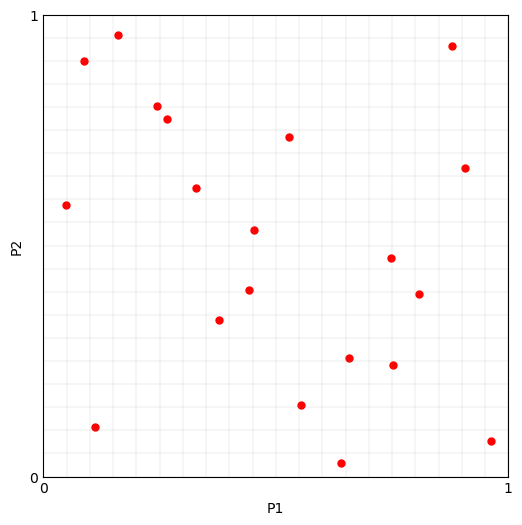

In [2]:
N = 20 # number of samples
P = 2 # number of dimensions

lhs_sampler = LatinHypercube(P)
lhs_set = lhs_sampler.random(N)

plotter.plot(lhs_set, M=0, x_label='P1', y_label='P2');

Now the aim is to add new samples without modifying the ones we already sampled. This procedure may cause two samples to fall in the same interval, even if they do not overlap in the initial set. 

As a first step we need to resize the binning of the intervals, we can see the effect of this by running `ExpandLHS.regridding` explicitly. The method `ExpandLHS.count_samples` allows to compute the number of samples in each interval for each dimension, this can be used to detect eventual overlaps. 
It is not necessary to call these two methods explicitly to expand an LHS, their outputs are used here for explanatory reason.

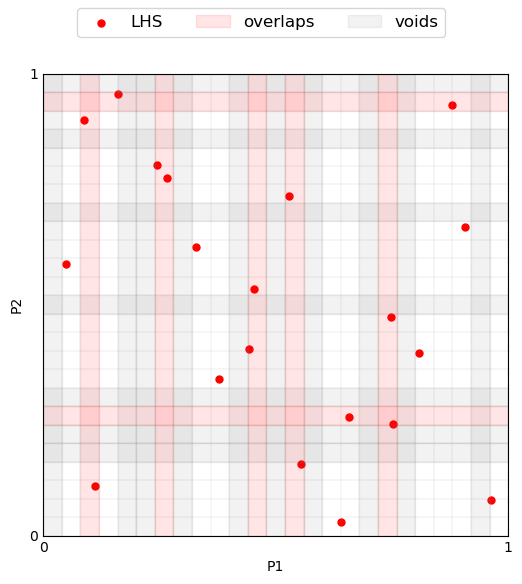

In [3]:
M = 5 # number of samples to add

eLHS = ExpandLHS(lhs_set)
voids = eLHS.regridding(M)
overlaps = eLHS.count_samples(M)

#the plot function internally compute both voids and overlaps
plotter.plot(lhs_set, M=M, labels='LHS', voids=voids, overlaps=overlaps, x_label='P1', y_label='P2');

The class call `ExpandLHS.__call__` performs the entire expansion process, thus it regrids the hypercube accounting for the new points and performs the sampling.

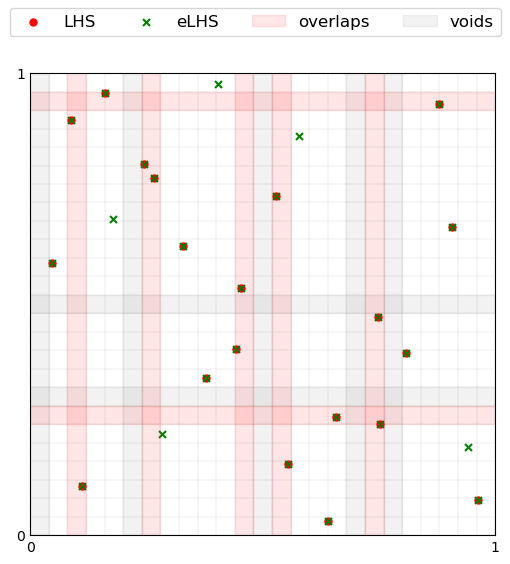

In [4]:
lhs_set_expanded = eLHS(M)
voids = eLHS.regridding(0, samples=lhs_set_expanded) #recompute voids on the expanded set

plotter.plot([lhs_set, lhs_set_expanded], M=0, labels=['LHS', 'eLHS'], \
    colors=['red', 'green'], markers=['o', 'x'], sizes=[25, 25], \
    index = 1, voids=voids, overlaps=overlaps);

### Degree of an expansion

The regridding of the space may cause some overlaps and voids, which imply that the new set is not a Latin Hypercube anymore.

We define a metric to measure the degree-of-LHS of a samples set. This estimate is performed with the method `ExpandLHS.degree`. A perfect Latin Hypercube has always a degree of 1. 

In [ ]:
degree = eLHS.degree(M)
print(f'degree-of-LHS = {degree:.3f}')

degree-of-LHS = 0.860


Using the method `ExpandLHS.optimal_expansion` it is possible to compute the degree-of-LHS for different expansion sizes in a given interval. 

In [ ]:
expansions = eLHS.optimal_expansion((4, 9), verbose=True)
print(f'List of expansions sorted by the corresponding degree:')
for expansion in expansions:
    print(f'({expansion[0]}, {expansion[1]:.4f})')

List of expansions sorted by the corresponding degree:

(0, 1.0000)

(8, 0.9464)

(9, 0.9310)

(4, 0.8750)

(7, 0.8704)

(5, 0.8600)

(6, 0.8462)



### Optimized expansion

Scipy's implementation of Latin Hypercube sampling allows to optimize the sample set using the centered discrepancy. A lower value for this metric corresponds to a better space-filling of the hypercube.

In [ ]:
from scipy.stats.qmc import discrepancy, geometric_discrepancy

N = 100
P = 6
M = 92

lhs_sampler = LatinHypercube(P)
lhs_set = lhs_sampler.random(N)
lhs_sampler_opt = LatinHypercube(P, optimization='random-cd')
lhs_set_opt = lhs_sampler_opt.random(N)

print(f'Discrepancy of LHS without optimization: {discrepancy(lhs_set):.4f}')
print(f'Discrepancy of LHS with optimization: {discrepancy(lhs_set_opt):.4f}')


Discrepancy of LHS without optimization: 0.0075
Discrepancy of LHS with optimization: 0.0025


When using `ExpandLHS.__call__` is it possible to ask for an optimized expansion with the keyword `optimize=`, where the available metrics are: \ 
- discrepancy ([Scipy.stats.qmc.discrepancy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.qmc.discrepancy.html#scipy.stats.qmc.discrepancy)) \
- geometric discrepancy ([Scipy.stats.qmc.geometric_discrepancy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.qmc.geometric_discrepancy.html#scipy.stats.qmc.geometric_discrepancy))

In [ ]:
lhs_set_expanded_opt = eLHS(M, optimize='discrepancy')

print(f'Discrepancy of eLHS without optimization: {discrepancy(lhs_set_expanded):.4f}')
print(f'Discrepancy of eLHS with optimization: {discrepancy(lhs_set_expanded_opt):.4f}')

Discrepancy of eLHS without optimization: 0.0023
Discrepancy of eLHS with optimization: 0.0002


In [ ]:
lhs_set_expanded_opt = eLHS(M, optimize='geometric_discrepancy')

print(f'Discrepancy of eLHS without optimization: {geometric_discrepancy(lhs_set_expanded):.4f}')
print(f'Discrepancy of eLHS with optimization: {geometric_discrepancy(lhs_set_expanded_opt):.4f}')